<h1 align="center">Incorporating the <i>field cancerization effect</i> to improve modeling of untreated breast cancer growth</h1>
<div align="center">Jainer A. Gómez<sup>a</sup>, Leidy J. Rojas<sup>a</sup>, David A. Miranda<sup>a</sup></div>
<div align="center"><sup>a</sup>Universidad Industrial de Santander, Cra 27 Cll 9, Bucaramanga, 680002, Santander, Colombia</div>

## 1. Modules importation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import basinhopping


In [2]:
import scr.data as data

In [3]:
import scr.methods as methods

## 2. Definitions and methods

### 2.1 Import data

In [4]:
# Experimental data are loaded from scr.data.
# The data module also defines the data arrays and model utilities.
data.df.head()


,time,values
0,1,0.44
1,2,0.65
2,3,0.79
3,4,0.93
4,5,1.06


### 2.2 Methods

#### 2.2.1 Method module overview
The numerical methods and reusable functions used in this notebook are implemented in `scr/methods.py`. This module contains:
- data import and experimental values,
- the baseline cancer growth model and the extended field cancerization model,
- objective functions for parameter calibration,
- simulation utilities and plotting helpers,
- predefined initial conditions and nominal parameter values.

#### 2.2.2 Model definitions
The module defines both the baseline cancer growth model without field effects and the extended model that includes the field cancerization effect through a coupled equation for normal preconditioned cells.

#### 2.2.3 Calibration objectives
The module also implements objective functions for parameter estimation, based on least-squares error between model predictions and the published experimental tumor volume data.

#### 2.2.4 Simulation utilities
Reusable plotting and residual analysis functions are provided in the module so that the notebook can focus on the results and interpretation rather than on low-level implementation details.

#### 2.2.5 Initial conditions and nominal parameters
The initial conditions for the tumor and preconditioned cell populations, as well as the nominal parameter values used in the simulations, are defined in `scr.methods`. This setup ensures consistency between the baseline and extended field cancerization models.

## 3. Explanation of the Parameter Selection Procedure

The objective of this analysis is to identify the set of model parameters that yields a simulation error less than or equal to 0.03 when compared against the experimental data. In this context, a Monte Carlo-based exploration of the parameter space is performed to evaluate the model performance under different parameter configurations.

Two representative parameter sets, denoted as $\hat{p}^1$ and $\hat{p}^2$, are considered for illustration. Although these parameter sets can produce qualitatively reasonable model behaviors, they do not satisfy the prescribed error criterion, since their associated RMSE remains above the threshold of 0.03.

This comparison highlights that, despite capturing the general trend of the system dynamics, not all parameter combinations within the explored space are admissible. Therefore, these examples serve to illustrate non-acceptable regions of the parameter space, motivating the need for a systematic identification of the admissible parameter set satisfying the defined error constraint.


## 4. Inverse modeling to reproduce Pei et al.'s results

In [5]:
# Simulation time
t_span = (1, 15)  # From day 1 to day 15

# Option A (smooth curve): many points between 1 and 15
t_eval = np.linspace(1, 15, 1000)

# Option B (only integer days): uncomment the next line
# t_eval = np.arange(1, 16)

# Solve the model WITHOUT field cancerization effect (note: y0 must be scalar -> only C0)
sol = solve_ivp(
    methods.cancer_model2,
    t_span,
    y0=[data.initial_conditions[0]],              # use only C0
    args=(data.r, data.x2, data.aK_T, data.lambda_ST),
    dense_output=True,
    t_eval=t_eval
)

# Extract results
t = sol.t
C = sol.y[0]                  # Cancer cells C(t)
volume = C / 1e7              # Normalize to cm^3 (if this is your convention)

# Prepare initial guess and run basinhopping on OF2 (objective without field cancerization effect)
p1 = [data.r, data.x2, data.aK_T, data.lambda_ST]

# Bounds for the optimizer
bounds = [
    (0.0, 2.0),      # r
    (1e-12, 1e-6),   # x2 = 1/K, must stay positive
    (0.0, 5.0),      # aK_T
    (0.0, 5.0)       # lambda_ST
]

minimizer_kwargs = {
    "method": "L-BFGS-B",
    "bounds": bounds
}

# Run basinhopping with bounded local minimization
pei_results = basinhopping(
    methods.OF2,
    p1,
    niter=100,
    minimizer_kwargs=minimizer_kwargs
)

print('fun:', pei_results.fun)
print('Optimized parameters for model without field effect:')
for symbol, name, unit, value in zip(
    data.parameter_symbols[:len(pei_results.x)],
    data.parameter_names[:len(pei_results.x)],
    data.parameter_units[:len(pei_results.x)],
    pei_results.x,
):
    print(f"\t{symbol} = {name} = {value:.6g} {unit}")


fun: 0.15818929326865763
Optimized parameters for model without field effect:
	x₁ = r = 0.00930831 (days)⁻¹
	x₂ = 1/K = 1e-06 (cells)⁻¹
	x₃ = aK_T = 2.0355 (days)⁻¹
	x₄ = λ_ST = 4.66694 (days)⁻¹


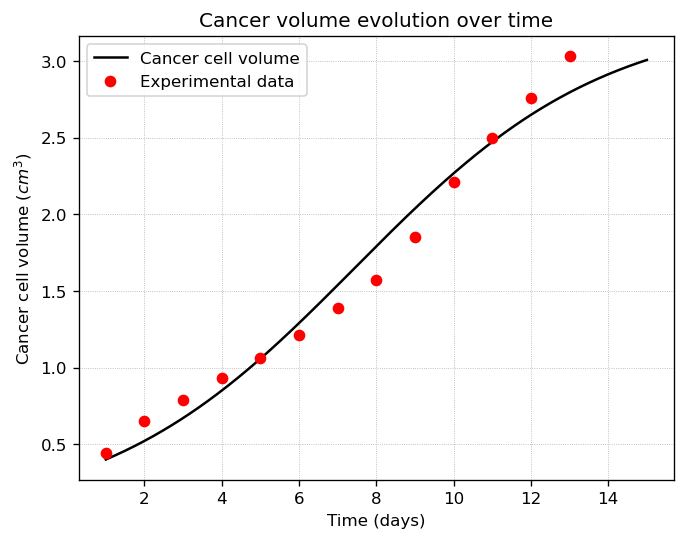

In [6]:
# Plot the fitted model without field cancerization effect using the optimized parameters
methods.plot_pei_model(pei_results.x)

## 5. Inverse modeling of the *field cancerization effect*

In [7]:
# Simulation time
t_span = (1, 15)  # From day 1 to day 15

# Option A (smooth curve): many points between 1 and 15
t_eval = np.linspace(1, 15, 1000)

# Option B (only integer days): uncomment the next line
# t_eval = np.arange(1, 16)

# Solve the model WITH field cancerization effect (C and N states)
sol = solve_ivp(
    methods.cancer_model,
    t_span,
    data.initial_conditions,                          # [C0, N0]
    args=(data.r, data.x2, data.aK_T, data.lambda_ST, data.lambda_N, data.gamma, data.gamma_prime),
    dense_output=True,
    t_eval=t_eval
)

# Extract results
t = sol.t
C = sol.y[0]                                     # Cancer cells C(t)
N = sol.y[1]                                     # Normal preconditioned cells N(t)
volume = C / 1e7                                 # Normalize to cm^3 (if this is your convention)

# Initial guess for parameters (with field cancerization effect)
p0 = [data.r, data.x2, data.aK_T, data.lambda_ST, data.lambda_N, data.gamma, data.gamma_prime]

# Global-local optimization (basinhopping) of the objective function with field cancerization effect
result = basinhopping(methods.OF, p0, niter=100)

print('fun:', result.fun)
print('Optimized parameters for model with field effect:')
for symbol, name, unit, value in zip(
    data.parameter_symbols[:len(result.x)],
    data.parameter_names[:len(result.x)],
    data.parameter_units[:len(result.x)],
    result.x,
):
    print(f"\t{symbol} = {name} = {value:.6g} {unit}")


fun: 0.019312858465057228
Optimized parameters for model with field effect:
	x₁ = r = 0.3913 (days)⁻¹
	x₂ = 1/K = 6.66667e-09 (cells)⁻¹
	x₃ = aK_T = 1.675 (days)⁻¹
	x₄ = λ_ST = 1.1835 (days)⁻¹
	x̂₁ = λ_N = 2.1162 (days)⁻¹
	p₁ = γ' = 1.824 (days)⁻¹
	p₂ = γ = 0.8135 (days)⁻¹


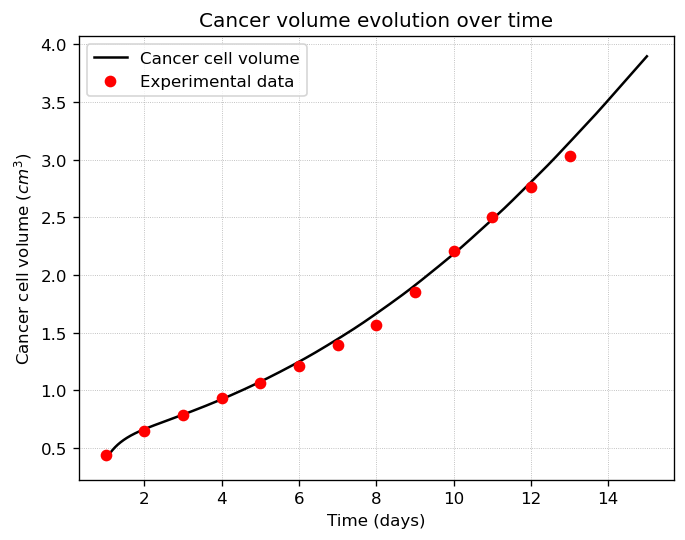

In [8]:
# Plot the fitted model with field cancerization effect using the optimized parameters
methods.plot_model(result.x)

## 6. Monte Carlo parameter exploration

### 6.1. Admissible parameter ranges obtained through Monte Carlo sampling

The parameter ranges reported in this section are those obtained through Monte Carlo sampling and satisfy the defined error criterion. These admissible intervals are used to identify parameter combinations that maintain simulation error below the threshold of 0.03.


### 6.2. Plotting the proposed model with parameter values from the admissible parameter ranges

Simulation 1:
x₁ = r = 0.391332 (days)⁻¹
x₂ = 1/K = 6.66667e-09 (cells)⁻¹
x₃ = aK_T = 1.67499 (days)⁻¹
x₄ = λ_ST = 1.18358 (days)⁻¹
x̂₁ = λ_N = 2.11637 (days)⁻¹
p₁ = γ' = 1.82178 (days)⁻¹
p₂ = γ = 0.813033 (days)⁻¹
----------------------------------------
Simulation 2:
x₁ = r = 0.391352 (days)⁻¹
x₂ = 1/K = 6.66667e-09 (cells)⁻¹
x₃ = aK_T = 1.67398 (days)⁻¹
x₄ = λ_ST = 1.18509 (days)⁻¹
x̂₁ = λ_N = 2.11603 (days)⁻¹
p₁ = γ' = 1.82586 (days)⁻¹
p₂ = γ = 0.813362 (days)⁻¹
----------------------------------------
Simulation 3:
x₁ = r = 0.391368 (days)⁻¹
x₂ = 1/K = 6.66667e-09 (cells)⁻¹
x₃ = aK_T = 1.67808 (days)⁻¹
x₄ = λ_ST = 1.18589 (days)⁻¹
x̂₁ = λ_N = 2.11637 (days)⁻¹
p₁ = γ' = 1.82386 (days)⁻¹
p₂ = γ = 0.813942 (days)⁻¹
----------------------------------------
Simulation 4:
x₁ = r = 0.391414 (days)⁻¹
x₂ = 1/K = 6.66667e-09 (cells)⁻¹
x₃ = aK_T = 1.6748 (days)⁻¹
x₄ = λ_ST = 1.18236 (days)⁻¹
x̂₁ = λ_N = 2.11614 (days)⁻¹
p₁ = γ' = 1.82139 (days)⁻¹
p₂ = γ = 0.813098 (days)⁻¹
------------------

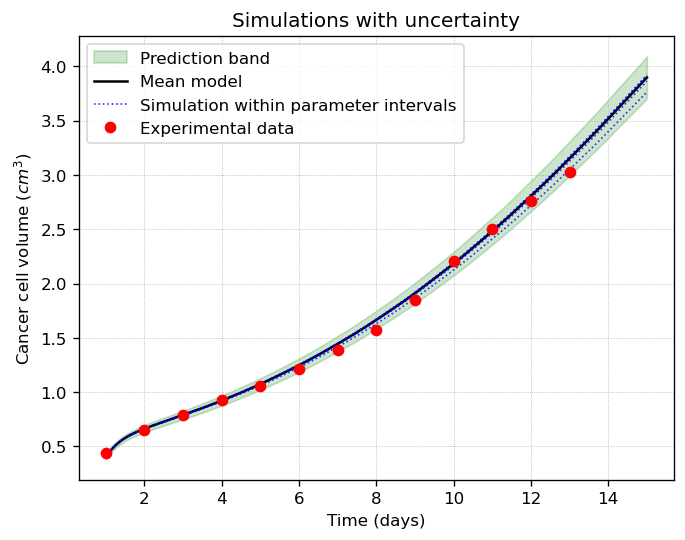

In [9]:
# Plot simulations with one random parameter set (plus the mean model)
methods.plot_models(data.p0, data.intervals, num_random=5)


### 6.3. Residual Analysis for Model Validation

In addition to the visual comparison between the model predictions and the experimental data, a residual analysis is performed to quantitatively evaluate the model performance. The residuals are defined as the difference between the experimental observations and the corresponding model predictions at the same time points.

For each parameter set, the system is first simulated using `solve_ivp`, and the tumor volume is computed. Then, the model output is interpolated to match the experimental time points, allowing a direct pointwise comparison. The residuals are computed as:



$$
\text{Residual} = \text{Experimental data} - \text{Model prediction}
$$

This procedure is applied to both the model with field effect and the model without the field effect. For the model with field effect, multiple parameter sets are randomly sampled from predefined intervals using a Monte Carlo approach, generating a distribution of residuals over the parameter space. This allows assessing not only a single trajectory but the variability of model errors across admissible parameter configurations.

The resulting scatter plot shows the residuals over time. The blue points correspond to the model with field effect evaluated over multiple parameter samples, while the red points represent the residuals of the model without the field effect. The horizontal dashed line at zero serves as a reference for perfect agreement between model and data.

This analysis provides a more rigorous validation of the model beyond visual inspection, allowing the identification of systematic deviations, bias, or dispersion in the prediction error across time.

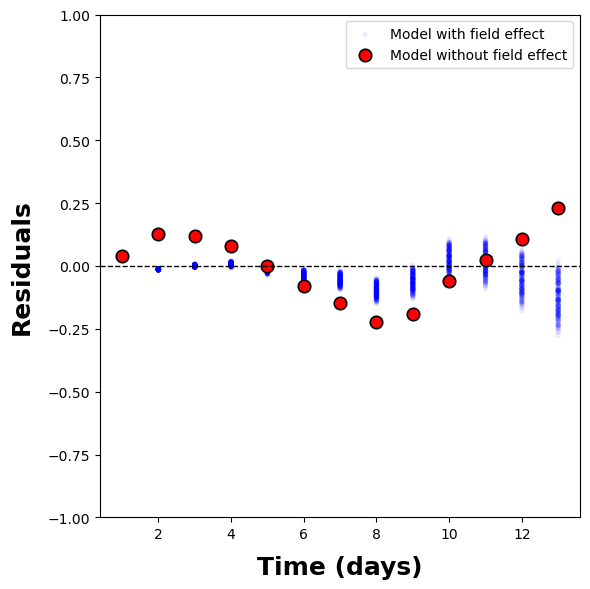

In [10]:
# Compute the residuals for the model with field effect using Monte Carlo sampling
# and compare them to the residuals from a baseline model without the field effect.
num_samples = 200
all_times = None
all_residuals = []

for _ in range(num_samples):
    p_rand = methods.pick_random_numbers(data.intervals)
    times_rand, residuals_rand = methods.compute_residuals_with_field(p_rand)
    if all_times is None:
        all_times = times_rand
    all_residuals.append(residuals_rand)

all_residuals = np.array(all_residuals)

p_simple = [1.396, 1.0 / 1.5e8, 1.645, 1.113]
times_simple, residuals_simple = methods.compute_residuals_baseline(p_simple)

plt.figure(figsize=(6, 6), dpi=100)
plt.axhline(0, linestyle='--', linewidth=1, color='black')
plt.scatter(
    np.tile(all_times, num_samples),
    all_residuals.flatten(),
    s=15,
    color='blue',
    edgecolors='none',
    alpha=0.08,
    label='Model with field effect'
)
plt.scatter(
    times_simple,
    residuals_simple,
    s=80,
    color='red',
    edgecolors='black',
    linewidths=1.2,
    label='Model without field effect'
)

plt.ylabel('Residuals', fontsize=18, fontweight='bold', rotation=90, labelpad=10)
plt.xlabel('Time (days)', fontsize=18, fontweight='bold', labelpad=10)
plt.legend()
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()


End!